# Milestone 2 — Final Model Selection, Explainability & Business Insights

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from insurance import config, data
from insurance.predict import load_bundle

sns.set_theme(style="whitegrid")
FIG = config.FIGURES_DIR
bundle = load_bundle()
metrics = json.loads(config.METRICS_PATH.read_text())
print("Final model:", bundle["model_name"])
print("Test metrics:", {k: round(v, 2) for k, v in bundle["metrics"].items() if k.startswith("test_")})
print("Best params:", bundle["best_params"])

Final model: LightGBM
Test metrics: {'test_MAE': 2328.38, 'test_RMSE': 2909.17, 'test_R2': 0.96, 'test_MAPE': 11.25, 'test_SMAPE': 10.91}
Best params: {}


## 1. Why this model?
Selected for the lowest test RMSE/MAE, strong R², stable cross-validation, a small train/test gap (low overfitting), and simple deployment.

In [2]:
comp = pd.DataFrame(metrics["model_comparison"])
comp[["model", "test_MAE", "test_RMSE", "test_R2", "cv_rmse_mean", "train_test_RMSE_gap"]].round(2).head(8)

,model,test_MAE,test_RMSE,test_R2,cv_rmse_mean,train_test_RMSE_gap
0,LightGBM,2328.38,2909.17,0.96,2975.28,195.22
1,HistGradientBoosting,2334.44,2911.71,0.96,2969.15,112.25
2,CatBoost,2344.53,2929.30,0.96,2969.11,132.70
3,GradientBoosting,2367.70,2944.15,0.96,2979.13,4.29
4,RandomForest,2380.82,3006.10,0.96,3060.94,1865.29
5,XGBoost,2427.64,3034.26,0.95,3122.07,906.18
6,ExtraTrees,2488.56,3152.68,0.95,3164.41,3152.68
7,Lasso,2709.29,3354.72,0.94,3356.09,7.23


## 2. Diagnostics: predicted vs actual and residuals

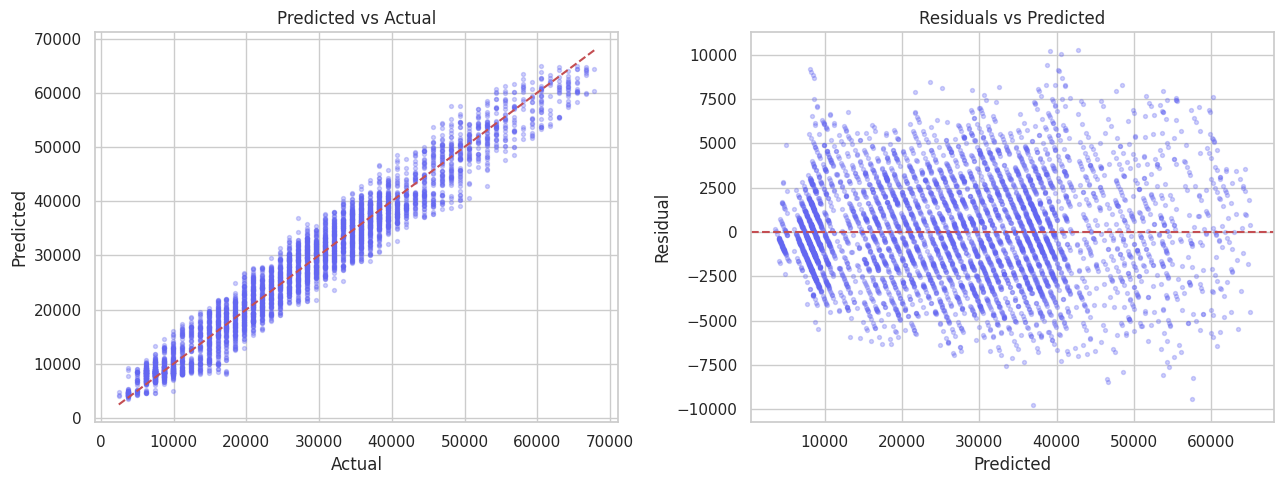

In [3]:
df = data.load_clean(); X, y = data.split_X_y(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE)
pred = bundle["pipeline"].predict(X_test)
resid = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred, s=8, alpha=0.3, color="#6366f1")
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--"); axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Predicted vs Actual")
axes[1].scatter(pred, resid, s=8, alpha=0.3, color="#6366f1")
axes[1].axhline(0, color="r", ls="--"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")
plt.tight_layout(); plt.savefig(FIG / "diagnostics.png", dpi=120); plt.show()

## 3. Explainability — permutation importance (model-agnostic)

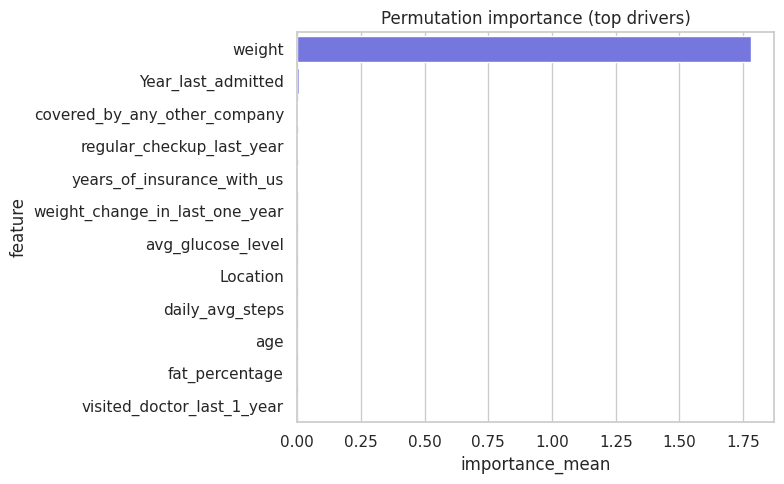

,feature,importance_mean,importance_std
0,weight,1.781844,0.022383
1,Year_last_admitted,0.009274,0.000445
2,covered_by_any_other_company,0.004130,0.000126
3,regular_checkup_last_year,0.002804,0.000342
4,years_of_insurance_with_us,0.001680,0.000094
5,weight_change_in_last_one_year,0.001213,0.000071
6,avg_glucose_level,0.000128,0.000054
7,Location,0.000125,0.000029
8,daily_avg_steps,0.000117,0.000086
9,age,0.000077,0.000056


In [4]:
imp = pd.read_csv(config.TABLES_DIR / "feature_importance.csv").head(12)
plt.figure(figsize=(8, 5))
sns.barplot(data=imp, y="feature", x="importance_mean", color="#6366f1")
plt.title("Permutation importance (top drivers)")
plt.tight_layout(); plt.savefig(FIG / "feature_importance.png", dpi=120); plt.show()
imp

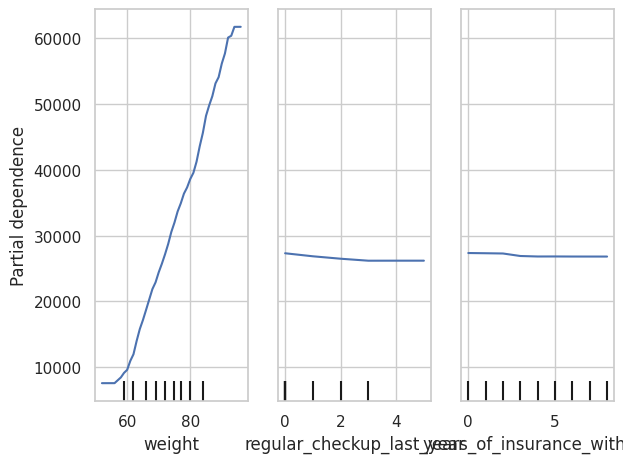

In [5]:
top_numeric = [f for f in imp["feature"] if f in config.NUMERIC_FEATURES + ["weight", "bmi", "avg_glucose_level", "age"]][:3]
top_numeric = top_numeric or ["weight"]
PartialDependenceDisplay.from_estimator(bundle["pipeline"], X_test, top_numeric, n_jobs=-1)
plt.tight_layout(); plt.savefig(FIG / "partial_dependence.png", dpi=120); plt.show()

## 4. Explainability — SHAP values
Permutation importance is model-agnostic but global. **SHAP** decomposes each individual prediction into per-feature contributions, giving both a richer global ranking (mean |SHAP|) and local explanations. We use `TreeExplainer` on the final boosting model, operating on the preprocessed feature space.

In [6]:
import shap

pipe = bundle["pipeline"]
model = pipe.named_steps["model"]
fe = pipe.named_steps["features"]
pre = pipe.named_steps["preprocess"]

# Transform a sample into the model's input space for speed
sample = X_test.sample(min(1500, len(X_test)), random_state=config.RANDOM_STATE)
X_trans = pre.transform(fe.transform(sample))
feat_names = list(pre.get_feature_names_out())
X_trans_df = pd.DataFrame(X_trans, columns=feat_names, index=sample.index)

try:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_trans_df)
    shap_ok = True
except Exception as exc:
    print("TreeExplainer unavailable for this model, skipping SHAP:", exc)
    shap_ok = False

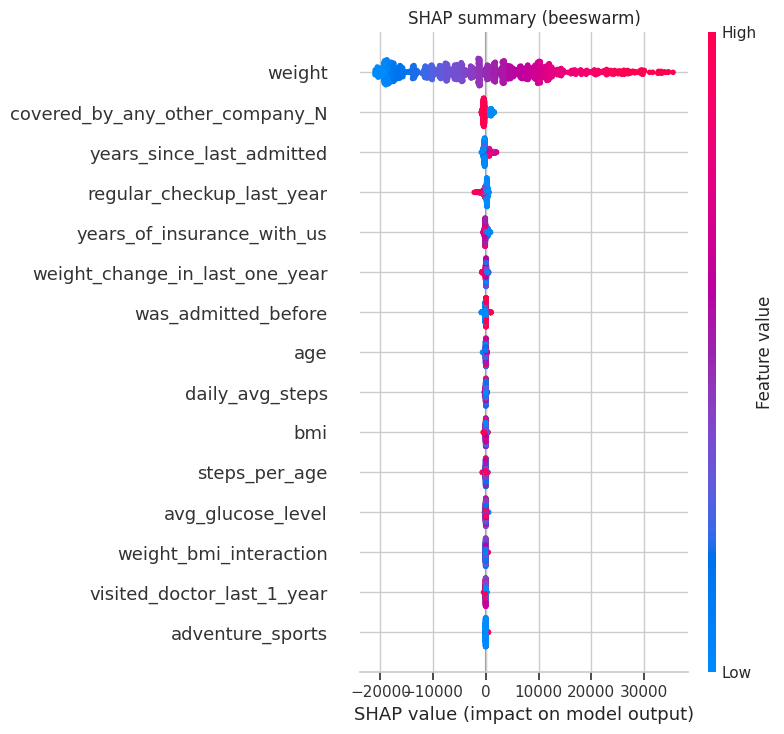

In [7]:
if shap_ok:
    shap.summary_plot(shap_values, X_trans_df, max_display=15, show=False)
    plt.title("SHAP summary (beeswarm)")
    plt.tight_layout(); plt.savefig(FIG / "shap_summary.png", dpi=120, bbox_inches="tight"); plt.show()

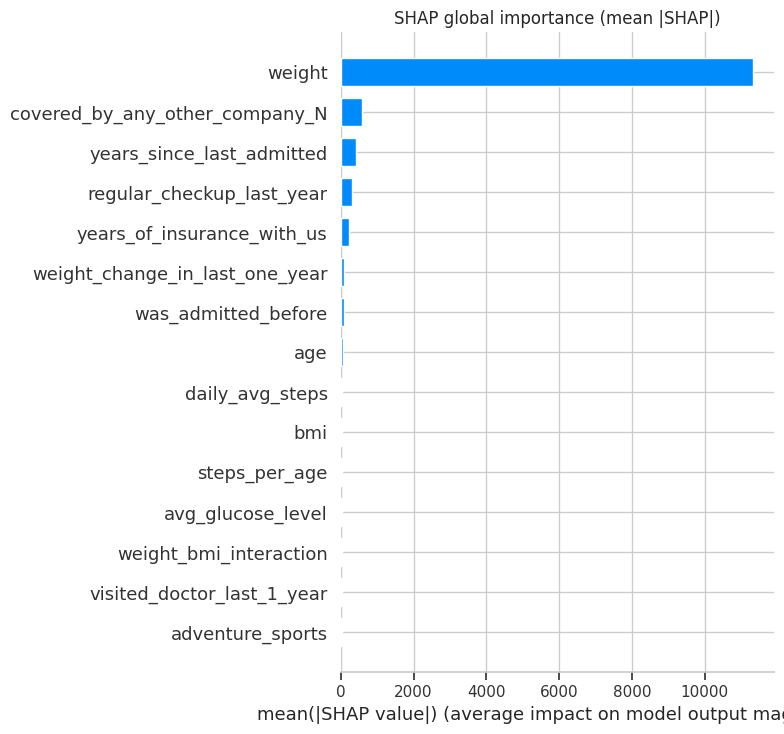

,feature,mean_abs_shap
0,weight,11343.256845
1,covered_by_any_other_company_N,570.341998
2,years_since_last_admitted,429.032772
3,regular_checkup_last_year,319.991792
4,years_of_insurance_with_us,215.215932
5,weight_change_in_last_one_year,88.408348
6,was_admitted_before,77.757152
7,age,52.071262
8,daily_avg_steps,44.729386
9,bmi,43.750788


In [8]:
if shap_ok:
    shap.summary_plot(shap_values, X_trans_df, plot_type="bar", max_display=15, show=False)
    plt.title("SHAP global importance (mean |SHAP|)")
    plt.tight_layout(); plt.savefig(FIG / "shap_importance_bar.png", dpi=120, bbox_inches="tight"); plt.show()

    shap_imp = (pd.DataFrame({"feature": feat_names,
                              "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
                .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
    shap_imp.to_csv(config.TABLES_DIR / "shap_importance.csv", index=False)
    display(shap_imp.head(12))

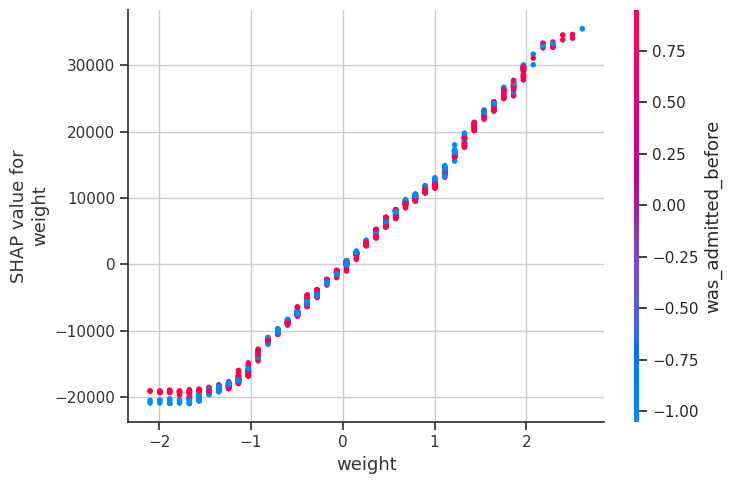

In [9]:
if shap_ok:
    top_feat = shap_imp.iloc[0]["feature"]
    shap.dependence_plot(top_feat, shap_values, X_trans_df, show=False)
    plt.tight_layout(); plt.savefig(FIG / "shap_dependence.png", dpi=120, bbox_inches="tight"); plt.show()

**SHAP observation:** SHAP confirms the permutation-importance ranking — `weight` is by far the dominant driver, followed by admission-history and other-coverage features. The beeswarm shows the *direction* of each effect (e.g. higher weight pushes predicted cost up). This agreement between two independent methods increases confidence in the drivers.

## 5. Decile gains / lift (business view)
Lift is a ranking diagnostic adapted here for the pricing regression: applicants are sorted by **predicted** cost into deciles (decile 1 = highest predicted). For each decile we compare mean predicted vs mean actual cost, the **lift** (decile mean actual ÷ overall mean), and the cumulative share of total cost captured. A well-ranked model concentrates high-cost customers in the top deciles.

In [10]:
gains = pd.DataFrame({"actual": y_test.to_numpy(), "pred": np.asarray(pred)})
gains["decile"] = pd.qcut(gains["pred"], 10, labels=list(range(10, 0, -1))).astype(int)
overall = gains["actual"].mean()

tbl = (gains.groupby("decile")
       .agg(n=("actual", "size"), mean_pred=("pred", "mean"), mean_actual=("actual", "mean"))
       .sort_index())
tbl["lift"] = (tbl["mean_actual"] / overall).round(3)
tbl["cum_capture_%"] = ((tbl["mean_actual"] * tbl["n"]).cumsum() / (gains["actual"].sum()) * 100).round(1)
tbl = tbl.round(1)
tbl.to_csv(config.TABLES_DIR / "decile_gains.csv")
tbl

,n,mean_pred,mean_actual,lift,cum_capture_%
decile,,,,,
1,500,53395.4,53479.1,2.0,19.7
2,500,40739.0,40842.9,1.5,34.8
3,500,36789.3,36711.5,1.4,48.3
4,500,33119.3,33031.7,1.2,60.5
5,500,29263.0,29388.9,1.1,71.3
6,500,25171.5,25131.6,0.9,80.6
7,500,20419.3,20388.1,0.8,88.1
8,500,15429.0,15590.4,0.6,93.9
9,500,9503.2,9469.7,0.3,97.4


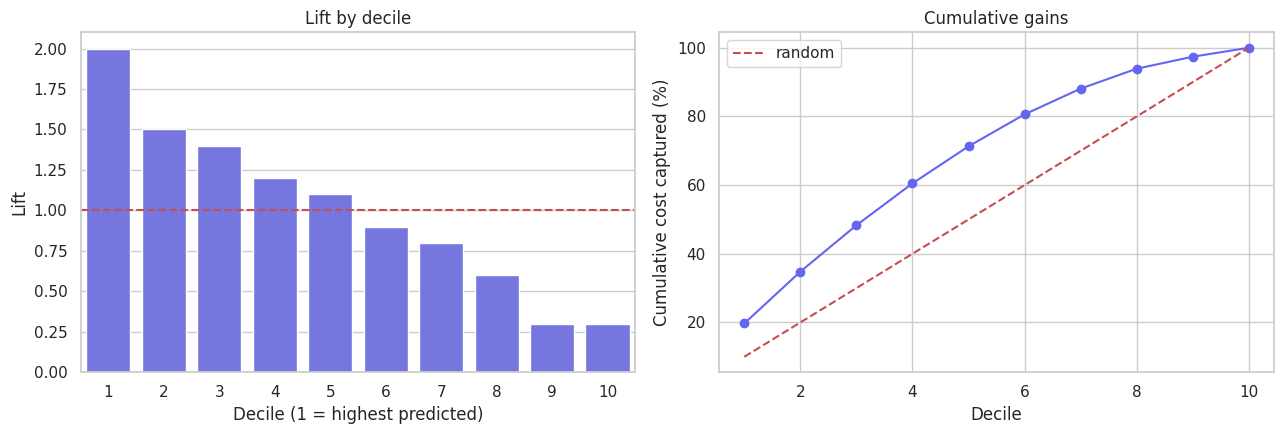

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=tbl.index, y=tbl["lift"], color="#6366f1", ax=axes[0])
axes[0].axhline(1.0, color="r", ls="--"); axes[0].set_xlabel("Decile (1 = highest predicted)")
axes[0].set_ylabel("Lift"); axes[0].set_title("Lift by decile")
axes[1].plot(range(1, 11), tbl["cum_capture_%"], marker="o", color="#6366f1")
axes[1].plot([1, 10], [10, 100], "r--", label="random")
axes[1].set_xlabel("Decile"); axes[1].set_ylabel("Cumulative cost captured (%)")
axes[1].set_title("Cumulative gains"); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG / "decile_gains.png", dpi=120); plt.show()

**Gains observation:** the top decile of predicted cost carries a lift well above 1.0 and the cumulative-gains curve sits above the random diagonal, confirming the model ranks applicants by cost effectively — useful for prioritising underwriting review and targeting high-cost segments for wellness programmes.

## 6. Conclusions & Business Insights
**Key drivers:** `weight` dominates, followed by admission history (`Year_last_admitted` / `years_since_last_admitted`), other-insurer coverage, preventive checkups, and weight change — confirmed by permutation importance *and* SHAP.

**Actionable insights & recommendations:**
1. **Pricing decision-support, not auto-underwriting** — use predictions to guide quote review and risk triage; keep a human in the loop.
2. **Manual review for extreme predictions** — route very high/unusual premiums (top decile) to an underwriting analyst.
3. **Wellness targeting** — build nudges around weight management, preventive checkups, and activity for high-risk segments.
4. **Admission-history follow-up** — prior hospitalisation should trigger documentation and preventive-health checks.
5. **Fairness governance** — review `Gender`/`Location` for proxy-discrimination before production; the dominance of `weight` should be validated for plausibility and leakage.
6. **Monitoring** — track drift, segment-level error, and override rates post-deployment.